In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt


1. Thresholding để phân đoạn ảnh

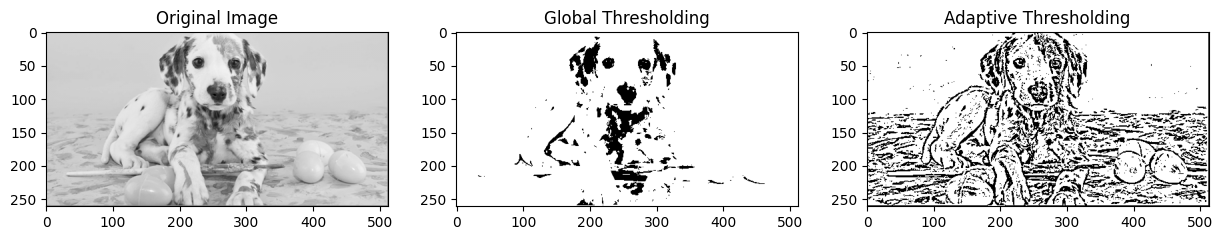

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh
img = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)
ret, thresh_global = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
thresh_adaptive = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

plt.figure(figsize=(15, 5))

# Ảnh 1
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')

# Ảnh 2
plt.subplot(1, 3, 2)
plt.imshow(thresh_global, cmap='gray')
plt.title('Global Thresholding')

# Ảnh 3
plt.subplot(1, 3, 3)
plt.imshow(thresh_adaptive, cmap='gray')
plt.title('Adaptive Thresholding')

plt.show()

2. Otsu algorithm để phân đoạn ảnh vân tay 


Ngưỡng Otsu tự động tìm được là: 138.0


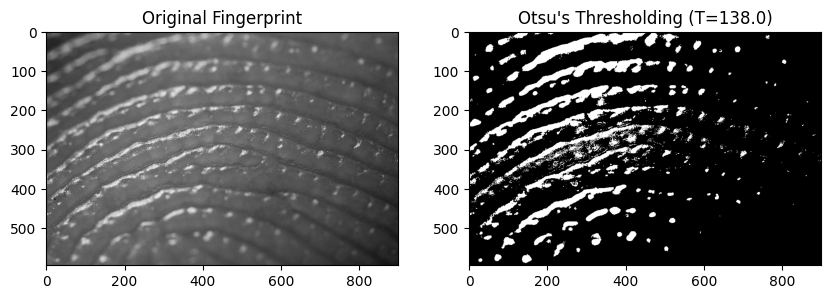

In [ ]:
# Đọc ảnh vân tay
fingerprint_img = cv2.imread('fingerprint.png', cv2.IMREAD_GRAYSCALE)

# Áp dụng thuật toán Otsu
ret_otsu, thresh_otsu = cv2.threshold(fingerprint_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Ngưỡng Otsu tự động tìm được là: {ret_otsu}")

# Hiển thị
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(fingerprint_img, cmap='gray')
plt.title('Original Fingerprint')

plt.subplot(1, 2, 2)
plt.imshow(thresh_otsu, cmap='gray')
plt.title(f"Otsu's Thresholding (T={ret_otsu})")

plt.show()

3. Clustering techniques trong phân đoạn ảnh, K-mean clustering


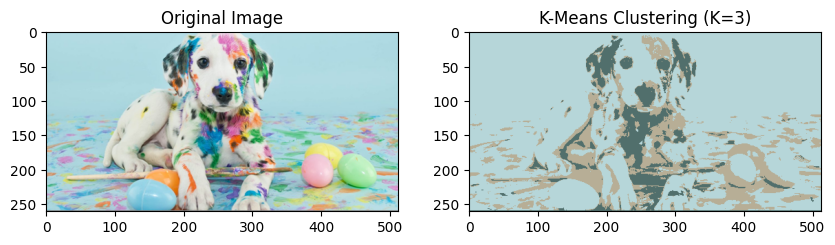

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc và chuyển đổi hệ màu
img_color = cv2.imread('image.png')
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

# Chuyển đổi dữ liệu để đưa vào K-means
pixel_values = img_color.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
K = 3

# Chạy K-means
_, labels, centers = cv2.kmeans(pixel_values, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Tái tạo ảnh
centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape((img_color.shape))

# Hiển thị
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_color)
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(segmented_image)
plt.title(f'K-Means Clustering (K={K})')

plt.show()

4. Sử dụng thuật toán Region growing


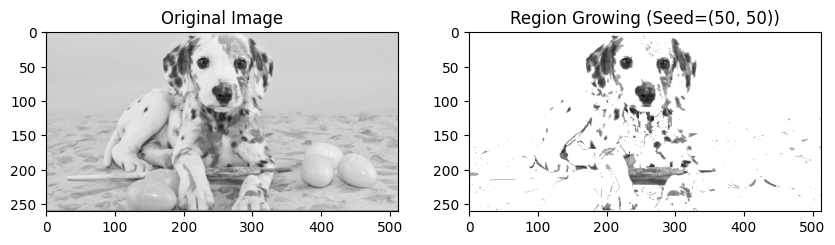

In [ ]:

img_rg = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)

# Khởi tạo mask và các thông số cho FloodFill (mô phỏng Region Growing)
h, w = img_rg.shape
mask = np.zeros((h + 2, w + 2), np.uint8)

seed_point = (50, 50) # Tọa độ điểm bắt đầu lan truyền
new_value = 255       # Màu của vùng mới (Trắng)
lo_diff = 10          # Dung sai dưới
up_diff = 10          # Dung sai trên

# Thực hiện FloodFill
img_floodfill = img_rg.copy()
cv2.floodFill(img_floodfill, mask, seed_point, new_value, lo_diff, up_diff)

# Hiển thị
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rg, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(img_floodfill, cmap='gray')
plt.title(f'Region Growing (Seed={seed_point})')

plt.show()

5. Sử dụng thuật toán Split and merge để phân đoạn ảnh


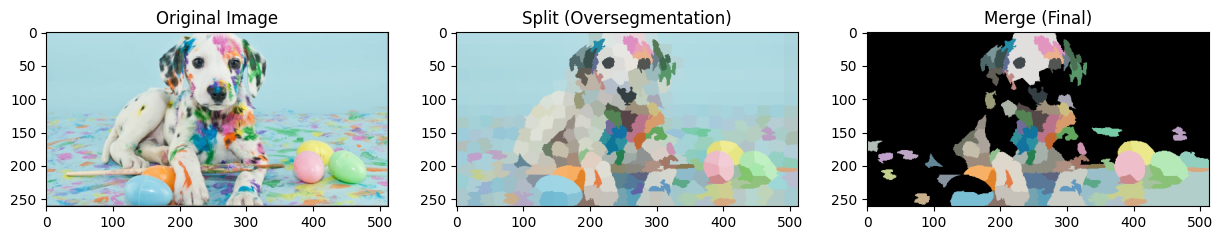

In [ ]:
import cv2
import matplotlib.pyplot as plt
from skimage import segmentation, color, graph

# Đọc ảnh
img_sm = cv2.imread('image.png')
img_sm = cv2.cvtColor(img_sm, cv2.COLOR_BGR2RGB)

# 1. SPLIT: Cắt thành siêu pixel
labels_split = segmentation.slic(img_sm, compactness=30, n_segments=400, start_label=1)
img_split = color.label2rgb(labels_split, img_sm, kind='avg')

# 2. MERGE: Sát nhập vùng dựa trên đồ thị màu
g = graph.rag_mean_color(img_sm, labels_split)

# Sử dụng cut_threshold thay cho merge_hierarchical để tránh lỗi phiên bản skimage
# thresh=29 (bạn có thể tinh chỉnh con số này để xem các mức độ gộp vùng khác nhau)
labels_merge = graph.cut_threshold(labels_split, g, thresh=29)
img_merge = color.label2rgb(labels_merge, img_sm, kind='avg')

# Hiển thị
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_sm)
plt.title('Original Image')

plt.subplot(1, 3, 2)
plt.imshow(img_split)
plt.title('Split (Oversegmentation)')

plt.subplot(1, 3, 3)
plt.imshow(img_merge)
plt.title('Merge (Final)')

plt.show()

6. Phân đoạn ảnh với Edge-based sigmentation


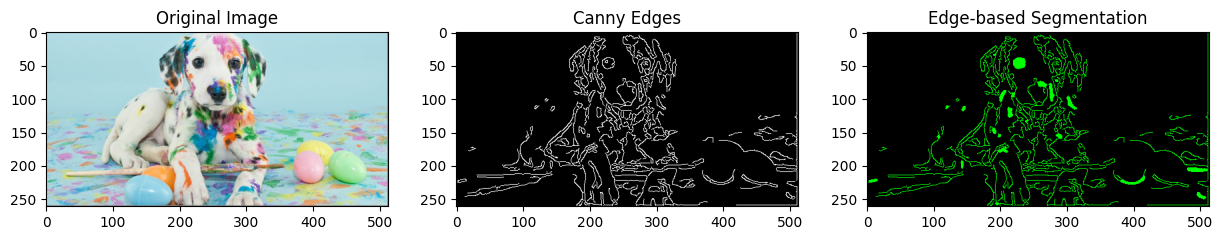

In [ ]:
img_edge = cv2.imread('image.png')
img_gray = cv2.cvtColor(img_edge, cv2.COLOR_BGR2GRAY)

# Làm mờ và tìm cạnh Canny
blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

# Tìm viền và tô kín vùng phân đoạn
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
segmented_by_edge = np.zeros_like(img_edge)
cv2.drawContours(segmented_by_edge, contours, -1, (0, 255, 0), thickness=cv2.FILLED)

# Chuyển lại hệ màu RGB để plot hiển thị đúng màu
img_edge_rgb = cv2.cvtColor(img_edge, cv2.COLOR_BGR2RGB)
segmented_rgb = cv2.cvtColor(segmented_by_edge, cv2.COLOR_BGR2RGB)

# Hiển thị
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_edge_rgb)
plt.title('Original Image')

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges')

plt.subplot(1, 3, 3)
plt.imshow(segmented_rgb)
plt.title('Edge-based Segmentation')

plt.show()